In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/output.csv")
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


In [ ]:
import re

def clean_text_summarization(text, lowercase=False):

    text = str(text)

    # remove HTML
    text = re.sub(r'<.*?>', '', text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove emojis (better regex)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)

    # keep important punctuation + apostrophes + hyphens
    text = re.sub(r"[^a-zA-Z0-9\s.,!?\'\-]", '', text)

    # optional lowercase
    if lowercase:
        text = text.lower()

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df["article"] = df["News body"].fillna("")
df["summary"] = df["Headline"]

df["clean_article"] = df["article"].apply(lambda x: clean_text_summarization(x, lowercase=True))

df["clean_summary"] = df["summary"].apply(lambda x: clean_text_summarization(x, lowercase=False))

df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content,article,summary,clean_article,clean_summary
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '...","Only FIVE internationals allowed, count em, FI...",Predicting Atlanta United's lineup against Col...,"only five internationals allowed, count em, fi...",Predicting Atlanta United's lineup against Col...
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q...",WASHINGTON -- Senate Majority Leader Mitch McC...,Mitch McConnell: DC statehood push is 'full bo...,washington -- senate majority leader mitch mcc...,Mitch McConnell DC statehood push is 'full bor...
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{},NORTH HIGHLANDS (CBS13) Fire damaged a home ...,Home In North Highlands Damaged By Fire,north highlands cbs13 fire damaged a home in n...,Home In North Highlands Damaged By Fire
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{},Meghan McCain is speaking out after a journali...,Meghan McCain blames 'liberal media' and 'thir...,meghan mccain is speaking out after a journali...,Meghan McCain blames 'liberal media' and 'thir...
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{},"1714: George I becomes King Georg Ludwig, Elec...",Today in History: Aug 1,"1714 george i becomes king georg ludwig, elect...",Today in History Aug 1


In [ ]:
# Sentence Tokenization
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Build TF-IDF Sentence Scorer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def extractive_summary(text, num_sentences=3):

    # Step 1: Split into sentences
    sentences = sent_tokenize(text)

    # Edge case
    if len(sentences) <= num_sentences:
        return text

    # Step 2: TF-IDF
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)

    # Step 3: Sentence scoring
    sentence_scores = tfidf_matrix.sum(axis=1)

    # Convert to array
    sentence_scores = np.array(sentence_scores).flatten()

    # Step 4: Rank sentences
    ranked_indices = np.argsort(sentence_scores)[::-1]

    # Step 5: Select top-k
    top_indices = sorted(ranked_indices[:num_sentences])

    # Step 6: Preserve original order
    summary = " ".join([sentences[i] for i in top_indices])

    return summary

In [ ]:
df["extractive_summary"] = df["clean_article"].apply(
    lambda x: extractive_summary(x, num_sentences=3)
)

## Evaluation

In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ae59c30f3264bbb04dbe5f2982ab50a7359cc3b13c5dfc3b46dfe21270b5666f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
# ROUGE Score

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'], use_stemmer=True
)

def evaluate_rouge(row):
    scores = scorer.score(row["clean_summary"], row["extractive_summary"])
    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure
    }

In [ ]:
# Apply evaluation

rouge_results = df.apply(evaluate_rouge, axis=1, result_type='expand')

df = pd.concat([df, rouge_results], axis=1)

In [ ]:
df[["rouge1","rouge2","rougeL"]].mean()

,0
rouge1,0.137964
rouge2,0.060512
rougeL,0.115207


## Save Results

In [ ]:
df[[
    "clean_article",
    "clean_summary",
    "extractive_summary",
    "rouge1",
    "rouge2",
    "rougeL"
]].to_csv("extractive_summarization_results.csv", index=False)

In [2]:
# Load extractive_summarization_results.csv
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Summarization/Extractive Baseline /extractive_summarization_results.csv")
df.head()

,clean_article,clean_summary,extractive_summary,rouge1,rouge2,rougeL
0,"only five internationals allowed, count em, fi...",Predicting Atlanta United's lineup against Col...,we've seen how he rotates or doesn't rotate in...,0.132231,0.050420,0.099174
1,washington -- senate majority leader mitch mcc...,Mitch McConnell DC statehood push is 'full bor...,washington -- senate majority leader mitch mcc...,0.082645,0.033613,0.066116
2,north highlands cbs13 fire damaged a home in n...,Home In North Highlands Damaged By Fire,north highlands cbs13 fire damaged a home in n...,0.260870,0.136364,0.217391
3,meghan mccain is speaking out after a journali...,Meghan McCain blames 'liberal media' and 'thir...,meghan mccain is speaking out after a journali...,0.326531,0.085106,0.244898
4,"1714 george i becomes king georg ludwig, elect...",Today in History Aug 1,"1798 battle of nile begins battle of nile, als...",0.018868,0.000000,0.018868


## Length-based EDA (Core for Summarization)

In [6]:
# Compute lengths
# Word-level length

df["article_len"] = df["clean_article"].astype(str).apply(lambda x: len(x.split()))
df["summary_len"] = df["clean_summary"].astype(str).apply(lambda x: len(x.split()))

# Compression ratio
df["compression_ratio"] = df["summary_len"] / df["article_len"]

df[["article_len", "summary_len", "compression_ratio"]].describe()

,article_len,summary_len,compression_ratio
count,113762.000000,113762.000000,113762.000000
mean,548.278292,10.308354,0.122957
std,689.427913,3.249001,0.369578
min,1.000000,1.000000,0.000109
25%,160.000000,8.000000,0.014406
50%,369.000000,10.000000,0.028455
75%,707.000000,12.000000,0.062500
max,36648.000000,41.000000,18.000000


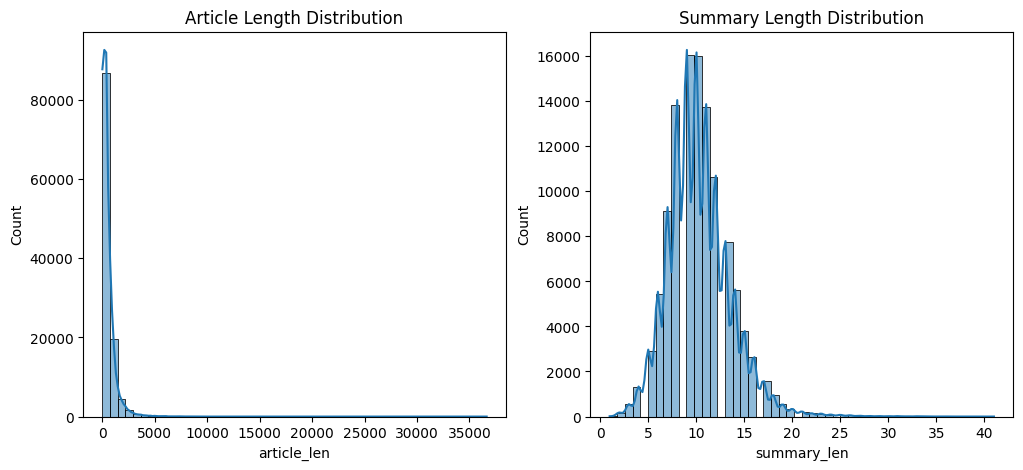

In [7]:
# Plot distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["article_len"], bins=50, kde=True)
plt.title("Article Length Distribution")

plt.subplot(1,2,2)
sns.histplot(df["summary_len"], bins=50, kde=True)
plt.title("Summary Length Distribution")

plt.show()

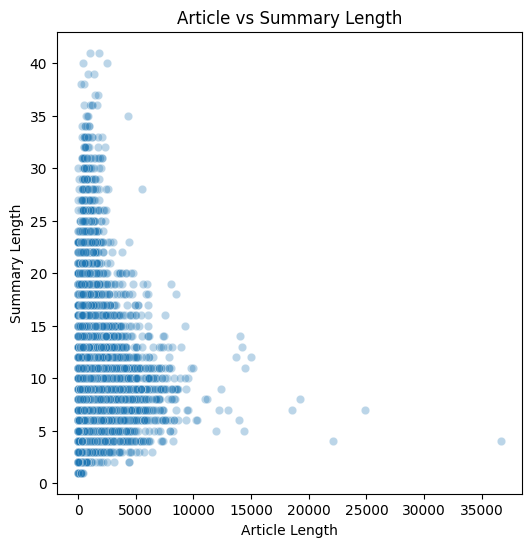

In [8]:
# Scatter plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["article_len"], y=df["summary_len"], alpha=0.3)
plt.xlabel("Article Length")
plt.ylabel("Summary Length")
plt.title("Article vs Summary Length")
plt.show()

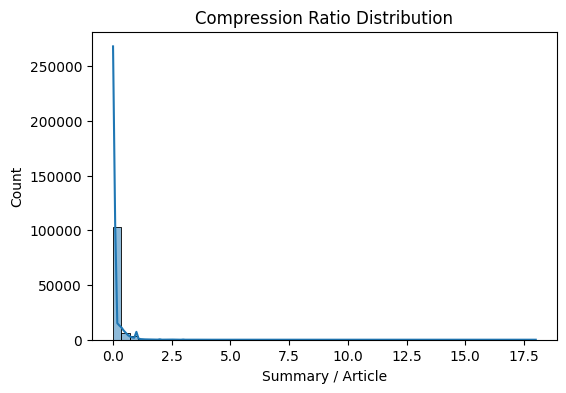

Average Compression Ratio: 0.122957460128961


In [9]:
# Compression ratio visualization
plt.figure(figsize=(6,4))
sns.histplot(df["compression_ratio"], bins=50, kde=True)
plt.title("Compression Ratio Distribution")
plt.xlabel("Summary / Article")
plt.show()

print("Average Compression Ratio:", df["compression_ratio"].mean())

## Vocabulary Size (After Cleaning)

In [12]:
from collections import Counter

# Article vocabulary
article_words = " ".join(df["clean_article"].astype(str)).split()
summary_words = " ".join(df["clean_summary"].astype(str)).split()

article_vocab = set(article_words)
summary_vocab = set(summary_words)

print("Article Vocabulary Size:", len(article_vocab))
print("Summary Vocabulary Size:", len(summary_vocab))

Article Vocabulary Size: 798220
Summary Vocabulary Size: 94694


## Most Frequent Unigrams & Bigrams

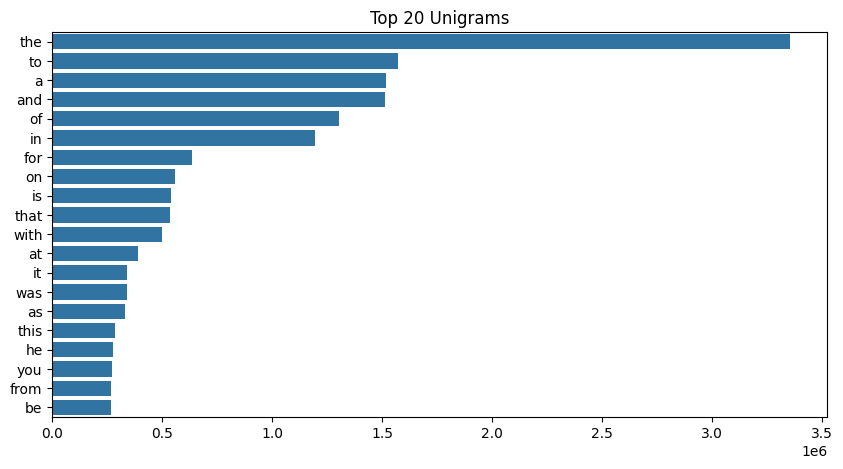

In [13]:
# Unigrams

from collections import Counter

top_unigrams = Counter(article_words).most_common(20)

words, counts = zip(*top_unigrams)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Unigrams")
plt.show()

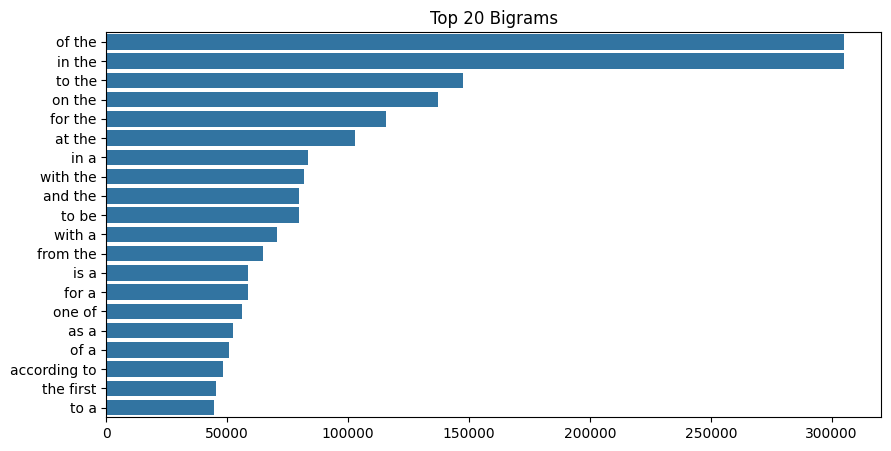

In [14]:
# Bigrams

from nltk.util import ngrams

bigrams = list(ngrams(article_words, 2))
top_bigrams = Counter(bigrams).most_common(20)

bigram_words = [" ".join(bg) for bg, _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

plt.figure(figsize=(10,5))
sns.barplot(x=bigram_counts, y=bigram_words)
plt.title("Top 20 Bigrams")
plt.show()

In [3]:
df1 = pd.read_csv("/content/drive/MyDrive/output.csv")
df1.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


## TF-IDF Heatmap (Category-wise)

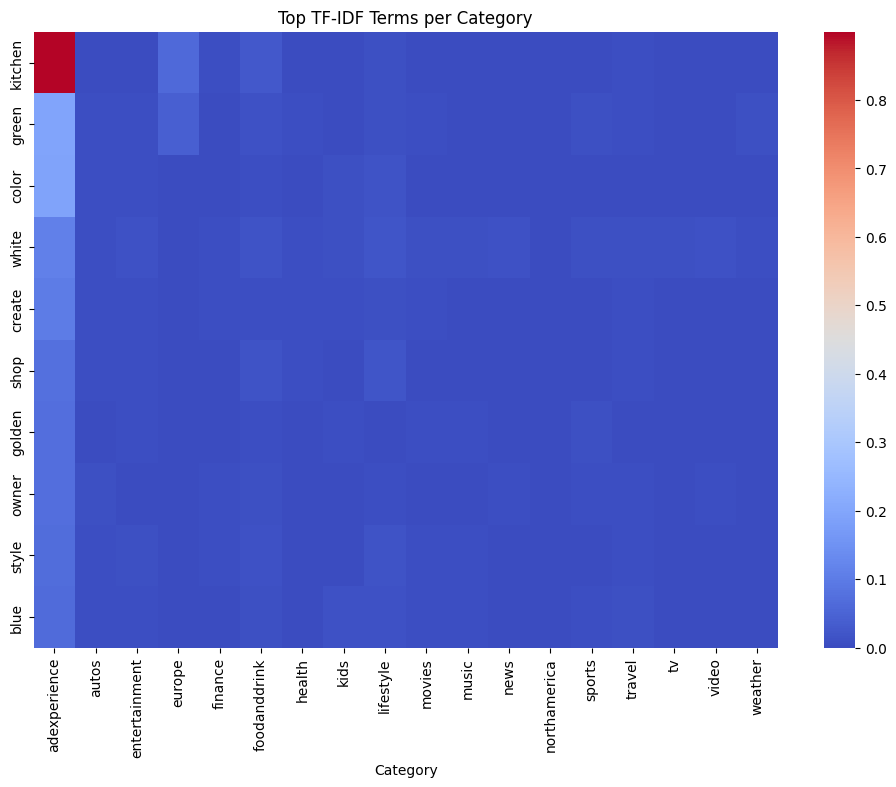

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

X = vectorizer.fit_transform(df["clean_article"].astype(str))
feature_names = vectorizer.get_feature_names_out()

# Convert to DataFrame
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)

# Add category
tfidf_df["Category"] = df1["Category"]

# Compute mean TF-IDF per category
category_tfidf = tfidf_df.groupby("Category").mean()

# Select top words per category
top_words = category_tfidf.T.nlargest(10, columns=category_tfidf.index)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(top_words, cmap="coolwarm")
plt.title("Top TF-IDF Terms per Category")
plt.show()

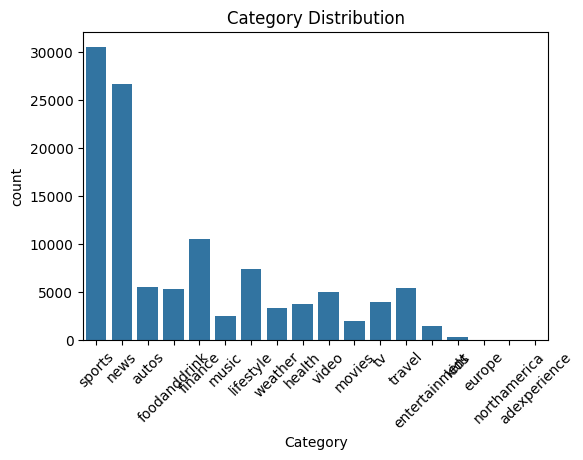

In [6]:
# Category Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df1, x="Category")
plt.title("Category Distribution")
plt.xticks(rotation=45)
plt.show()